In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

---
---

## 甚麼都不做, 直接跑隨機森林, 結論是還是要做features selection, 效果會較佳

In [11]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_imputed, y_tr)

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_te_imputed)

    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.8651, FAR=0.0684
sensitivy =  0.0 %
specificity =  93.16 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9206, FAR=0.0342
sensitivy =  33.33 %
specificity =  96.58 %
GM =  56.74 %
----------------------------------------
fold=3, acc=0.8889, FAR=0.0513
sensitivy =  11.11 %
specificity =  94.87 %
GM =  32.47 %
----------------------------------------
fold=4, acc=0.9280, FAR=0.0342
sensitivy =  37.5 %
specificity =  96.58 %
GM =  60.18 %
----------------------------------------
fold=5, acc=0.9280, FAR=0.0171
sensitivy =  12.5 %
specificity =  98.29 %
GM =  35.05 %
----------------------------------------
fold=6, acc=0.9280, FAR=0.0427
sensitivy =  50.0 %
specificity =  95.73 %
GM =  69.18 %
----------------------------------------
fold=7, acc=0.8800, FAR=0.0598
sensitivy =  0.0 %
specificity =  94.02 %
GM =  0.0 %
----------------------------------------
fold=8, acc=0.9280, FAR=0.0256
sensitivy =  25.0 %
specificity =  97.44 %
GM =  49.35 %
-------------

---
---
## 二階段的logistic regression, 還是未獲得可用解（實務上沒收斂）
#### 可能要做降維或做L1, L2懲罰


In [46]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

target_fold = 6
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    if fold != target_fold:
        continue

    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    # 1) KNN 只 fit 在當折 train
    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imp = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imp, y_tr)
    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imp.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imp.columns)

    # 3) 標準化（只用 train 估參數）
    scaler = StandardScaler()
    X_tr_sel = X_tr_imp[selected]
    X_te_sel = X_te_imp[selected]
    X_tr_z = pd.DataFrame(scaler.fit_transform(X_tr_sel), columns=selected, index=X_tr_sel.index)
    X_te_z = pd.DataFrame(scaler.transform(X_te_sel), columns=selected, index=X_te_sel.index)

    # 4) SMOTE 只在 train 上；採 0.7 打破對稱
    smote = SMOTE(sampling_strategy=0.7, k_neighbors=5, random_state=42)
    X_bal, y_bal = smote.fit_resample(X_tr_z, y_tr)

    # 6) 當折 train 上估計 Logit 並印 summary（無懲罰）
    Xb = sm.add_constant(X_bal, has_constant='add')
    res = sm.Logit(y_bal.values, Xb).fit(method='bfgs', maxiter=2000, disp=True)
    print("\n========== statsmodels Logit 第六折 summary ==========")
    print(res.summary())
    break

Optimization terminated successfully.
         Current function value: 0.000014
         Iterations: 845
         Function evaluations: 852
         Gradient evaluations: 852

========== statsmodels Logit 第六折 summary ==========
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1790
Model:                          Logit   Df Residuals:                     1606
Method:                           MLE   Df Model:                          183
Date:                Tue, 23 Sep 2025   Pseudo R-squ.:                   1.000
Time:                        22:14:02   Log-Likelihood:              -0.024192
converged:                       True   LL-Null:                       -1212.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

---
---


## 目前最好的一次fold, 來做analysis, 也是一種方法

In [18]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def tri_class(y_proba_fail, low, high):
    """
    輸入 y_proba
    回傳 tri_class {-1:pass, 0:not sure, 1:Fail}
    """
    if not (0<=low<high<=1):
        raise ValueError('low必須<high, 且都在[0, 1]')
    tri = np.where(y_proba_fail<=low, -1, np.where(y_proba_fail>=high,1 ,0))
    return tri

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

selected_by_fold = {}
all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imputed, y_tr)

    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imputed.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imputed.columns)

    selected_by_fold[fold] = selected

    coef_sel = coef.loc[selected]
    df_rank = (pd.DataFrame({"feature": coef_sel.index, "coef": coef_sel.values}).assign(l1_abs=lambda d: d["coef"].abs()).sort_values("l1_abs", ascending=False).reset_index(drop=True))
    df_rank["rank_l1_abs"] = np.arange(1, len(df_rank)+1)

    if fold == 6:
        print(f"[Fold 6] selected features = {len(selected)}")
        print("[Fold 6] order by |coef| (descending):")
        print(df_rank[["rank_l1_abs","feature","coef","l1_abs"]].head(30).to_string(index=False))
        print("（排序標準：|L1 係數| 由大到小）")

    X_tr_selected = X_tr_imputed[selected].copy()
    X_te_selected = X_te_imputed[selected].copy()

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_selected, y_tr)

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_te_selected)

    if fold == 6:
        y_prob = rf.predict_proba(X_te_selected)[:, 1]
        tri = tri_class(y_prob, low=0.3, high=0.5)
        out = pd.DataFrame({"y_true": y_te.values, "y_pred_bin": y_pred, "p_fail": y_prob, "tri_class": tri}, index=X_te_selected.index)
        print(out.head())
        print("tri_class counts:\n", out["tri_class"].value_counts().sort_index())
        
        y_true_s = y_te.rename("y_true")
        y_pred_s = pd.Series(y_pred, index=X_te_selected.index, name="y_pred")
        fold6_secom_result = pd.concat([X_te_selected, y_true_s, y_pred_s], axis=1)
        print(fold6_secom_result.head(1))
        fold6_secom_test = secom.loc[X_te_selected.index].copy()
        fold6_secom_test["y_true"] = y_true_s
        fold6_secom_test["y_pred"] = y_pred_s
        print(confusion_matrix(y_te, y_pred, labels=[0, 1]))
        
    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.8651, FAR=0.0684
sensitivy =  0.0 %
specificity =  93.16 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9048, FAR=0.0513
sensitivy =  33.33 %
specificity =  94.87 %
GM =  56.24 %
----------------------------------------
fold=3, acc=0.8730, FAR=0.0684
sensitivy =  11.11 %
specificity =  93.16 %
GM =  32.17 %
----------------------------------------
fold=4, acc=0.9040, FAR=0.0598
sensitivy =  37.5 %
specificity =  94.02 %
GM =  59.38 %
----------------------------------------
fold=5, acc=0.9200, FAR=0.0342
sensitivy =  25.0 %
specificity =  96.58 %
GM =  49.14 %
----------------------------------------
[Fold 6] selected features = 183
[Fold 6] order by |coef| (descending):
 rank_l1_abs feature      coef   l1_abs
           1    x446  2.168428 2.168428
           2    x178 -1.616071 1.616071
           3    x334  1.588997 1.588997
           4    x407  0.857853 0.857853
           5    x337 -0.711831 0.711831
           6     x15 -0.653757 0.653757
    

---
---

## 調整X, y在cv上的比例（進行中）

<Axes: xlabel='pca1', ylabel='pca2'>

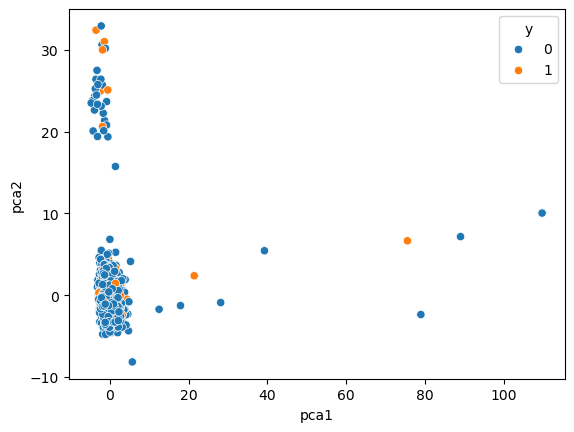

In [27]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
scaler = StandardScaler()
pca = PCA(n_components=10, random_state=42)

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns=['pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7', 'pca8', 'pca9', 'pca10'])
df['y'] = y
sns.scatterplot(data=df, x='pca1', y='pca2', hue='y')

In [52]:
clf = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
clf.fit(X_pca, y)

proba = clf.predict_proba(X_pca)[:,1]

idx_y0 = np.where(proba<0.50)[0]
idx_y1 = np.where(proba>=0.50)[0]

X_y0 = X.iloc[idx_y0].copy()
X_y1 = X.iloc[idx_y1].copy()

purity_y0 = y.iloc[idx_y0].mean()
purity_y1 = y.iloc[idx_y1].mean() 

In [54]:
base = y.mean()

purity_y0 = y.iloc[idx_y0].mean() if len(idx_y0)>0 else np.nan
purity_y1 = y.iloc[idx_y1].mean() if len(idx_y1)>0 else np.nan

print(f"n_y0={len(idx_y0)}, purity_y0={purity_y0:.3f}  |  n_y1={len(idx_y1)}, purity_y1={purity_y1:.3f}  |  base={base:.3f}")


n_y0=1000, purity_y0=0.040  |  n_y1=567, purity_y1=0.113  |  base=0.066


In [55]:
clf.classes_, proba.min(), proba.max(), proba.mean()

(array([0, 1]), 0.014938047897646533, 0.9999388975507139, 0.4556250205984148)

In [56]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

# 1) 先把樣本標上桶別：高信心0、高信心1、其他
bucket = np.full(len(y), 'R', dtype=object)
bucket[idx_y0] = 'H0'
bucket[idx_y1] = 'H1'

# 2) 建立分層鍵：同時顧到 y 與 高信心桶別
strat_key = y.astype(str) + "|" + pd.Series(bucket, index=y.index)

# 若某些 (y,bucket) 太少導致 5 折失敗，可把 'R' 之外的罕見桶合併回 'R'
vc = strat_key.value_counts()
need_merge = vc[vc < 5].index
if len(need_merge) > 0:
    mask = strat_key.isin(need_merge)
    # 把那些太小的鍵的 bucket 改回 'R'
    bucket2 = pd.Series(bucket, index=y.index)
    bucket2[mask] = 'R'
    strat_key = y.astype(str) + "|" + bucket2

# 3) 依 strat_key 做 5 折 split（同時維持 y 與桶別比例）
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = [(tr, te) for tr, te in skf.split(np.zeros(len(y)), strat_key)]

# 4) 快速檢查每折的 y 與桶別分布
for k, (_, te) in enumerate(folds, 1):
    y_te = y.iloc[te]
    b_te = pd.Series(bucket, index=y.index).iloc[te]
    print(f"Fold{k}: y=1比例={y_te.mean():.3f} | H0={np.mean(b_te=='H0'):.3f} H1={np.mean(b_te=='H1'):.3f}")


Fold1: y=1比例=0.067 | H0=0.637 H1=0.363
Fold2: y=1比例=0.067 | H0=0.637 H1=0.363
Fold3: y=1比例=0.064 | H0=0.639 H1=0.361
Fold4: y=1比例=0.067 | H0=0.639 H1=0.361
Fold5: y=1比例=0.067 | H0=0.639 H1=0.361


In [61]:
# 先把全體樣本標桶：H0 / H1 / R（你前面已算好 idx_y0, idx_y1, proba）
bucket = np.full(len(y), 'R', dtype=object)
bucket[idx_y0] = 'H0'
bucket[idx_y1] = 'H1'

# 分層鍵：同時顧到 y 與 bucket（簡單版）
strat_key = y.astype(str) + "|" + pd.Series(bucket, index=y.index)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = [(tr, te) for tr, te in skf.split(np.zeros(len(y)), strat_key)]

# 逐折抓出「training 中的 H0/H1 樣本索引」與對應資料
per_fold = []  # 存起來以便後續使用
for k, (tr, te) in enumerate(folds, 1):
    tr = np.array(tr)

    tr_H0 = np.intersect1d(tr, idx_y0)   # 第 k 折的 training∩H0
    tr_H1 = np.intersect1d(tr, idx_y1)   # 第 k 折的 training∩H1

    X_tr_H0 = X.iloc[tr_H0]
    y_tr_H0 = y.iloc[tr_H0]
    X_tr_H1 = X.iloc[tr_H1]
    y_tr_H1 = y.iloc[tr_H1]

    print(f"Fold{k}: train | H0 n={len(tr_H0)}, y=1比例={y_tr_H0.mean():.3f} | H1 n={len(tr_H1)}, y=1比例={y_tr_H1.mean():.3f}")

    per_fold.append({
        "train_idx": tr,
        "test_idx": te,
        "train_H0_idx": tr_H0,
        "train_H1_idx": tr_H1,
        "X_train_H0": X_tr_H0, "y_train_H0": y_tr_H0,
        "X_train_H1": X_tr_H1, "y_train_H1": y_tr_H1,
    })

Fold1: train | H0 n=800, y=1比例=0.040 | H1 n=453, y=1比例=0.113
Fold2: train | H0 n=800, y=1比例=0.040 | H1 n=453, y=1比例=0.113
Fold3: train | H0 n=800, y=1比例=0.040 | H1 n=454, y=1比例=0.115
Fold4: train | H0 n=800, y=1比例=0.040 | H1 n=454, y=1比例=0.112
Fold5: train | H0 n=800, y=1比例=0.040 | H1 n=454, y=1比例=0.112


In [62]:
scores = []
for k, (tr, te) in enumerate(folds, 1):
    X_tr, y_tr = X.iloc[tr].copy(), y.iloc[tr].copy()
    X_te, y_te = X.iloc[te].copy(), y.iloc[te].copy()
    b_tr = pd.Series(bucket, index=y.index).iloc[tr].values
    b_te = pd.Series(bucket, index=y.index).iloc[te].values

    # 1) 折內前處理
    imputer = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imp = imputer.fit_transform(X_tr)
    X_te_imp = imputer.transform(X_te)
    scaler = StandardScaler().fit(X_tr_imp)
    X_tr_std = scaler.transform(X_tr_imp)
    X_te_std = scaler.transform(X_te_imp)

    # 2) 基礎模型（全訓練）
    base_clf = LogisticRegression(max_iter=1000).fit(X_tr_std, y_tr.values)

    # 3) 找到訓練集中 H0/H1 的「位置索引」
    pos_in_tr = pd.Series(np.arange(len(tr)), index=tr)
    H0_pos = pos_in_tr[np.intersect1d(tr, idx_y0)].values
    H1_pos = pos_in_tr[np.intersect1d(tr, idx_y1)].values

    # 4) 為兩桶建立專家；若該桶只有單一類，改用常數機率（桶內正類比例）
    clf_H0 = None; const_p_H0 = None
    if len(H0_pos) >= 10 and np.unique(y_tr.iloc[H0_pos]).size >= 2:
        clf_H0 = LogisticRegression(max_iter=1000).fit(X_tr_std[H0_pos], y_tr.iloc[H0_pos].values)
    else:
        const_p_H0 = float(y_tr.iloc[H0_pos].mean()) if len(H0_pos)>0 else float(y_tr.mean())

    clf_H1 = None; const_p_H1 = None
    if len(H1_pos) >= 10 and np.unique(y_tr.iloc[H1_pos]).size >= 2:
        clf_H1 = LogisticRegression(max_iter=1000).fit(X_tr_std[H1_pos], y_tr.iloc[H1_pos].values)
    else:
        const_p_H1 = float(y_tr.iloc[H1_pos].mean()) if len(H1_pos)>0 else float(y_tr.mean())

    # 5) 推論：H1 用 H1 專家/常數，H0 其餘用 H0 專家/常數
    p = np.empty(len(te))
    m1 = (b_te == 'H1')
    if clf_H1 is not None:
        p[m1] = clf_H1.predict_proba(X_te_std[m1])[:,1]
    else:
        p[m1] = const_p_H1

    if clf_H0 is not None:
        p[~m1] = clf_H0.predict_proba(X_te_std[~m1])[:,1]
    else:
        p[~m1] = const_p_H0

    y_pred = (p >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    FAR  = fp/(fp+tn) if (fp+tn)>0 else 0.0
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    scores.append((k, FAR, sens, spec))

scores

[(1, 0.08532423208191127, 0.09523809523809523, 0.9146757679180887),
 (2, 0.04778156996587031, 0.047619047619047616, 0.9522184300341296),
 (3, 0.04778156996587031, 0.05, 0.9522184300341296),
 (4, 0.0410958904109589, 0.19047619047619047, 0.958904109589041),
 (5, 0.04794520547945205, 0.19047619047619047, 0.952054794520548)]

---
---

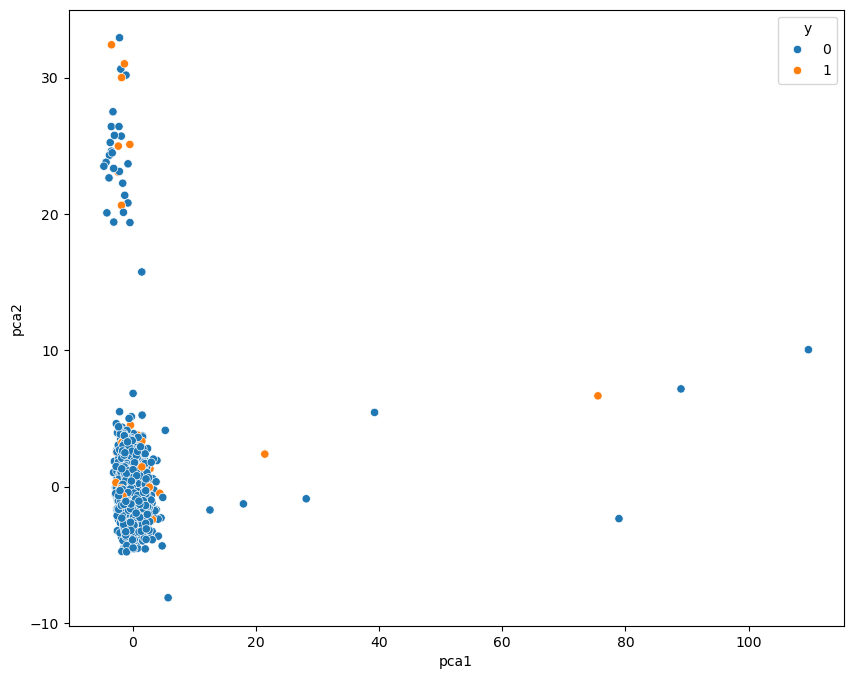

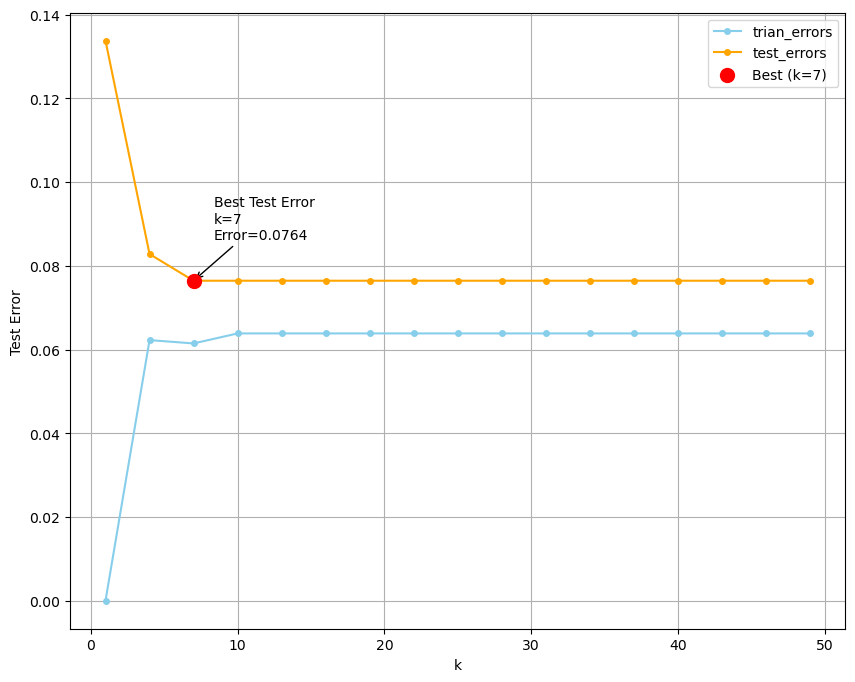

In [26]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
scaler = StandardScaler()
pca = PCA(n_components=2, random_state=42)

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)
X_pca = pca.fit_transform(X_scaled)

knc = KNeighborsClassifier(n_neighbors=10)
knc.fit(X_pca, y)

df = pd.DataFrame(X_pca, columns=['pca1', 'pca2'])
df['y'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(df, x='pca1', y='pca2', hue='y')
plt.xlabel('pca1')
plt.ylabel("pca2")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

N = len(X_train)
train_errors = []
test_errors = []
effective = []
ks = list(range(1, 51, 3))
for k in range(1, 51, 3):
    knc = KNeighborsClassifier(n_neighbors=k)
    knc.fit(X_train, y_train)
    y_pred_train = knc.predict(X_train)
    y_pred_test = knc.predict(X_test)

    err_train = zero_one_loss(y_train, y_pred_train)
    err_test = zero_one_loss(y_test, y_pred_test)

    train_errors.append(err_train)
    test_errors.append(err_test)

    effective.append(N/k)

index_min = int(np.array(test_errors).argmin())
best_k = ks[index_min]

best_test_error = test_errors[np.argmin(test_errors)]

plt.figure(figsize=(10, 8))
plt.plot(ks, train_errors, marker='o', markersize=4, color='skyblue', label='trian_errors')
plt.plot(ks, test_errors, marker='o', markersize=4, color='orange', label='test_errors')
plt.scatter(best_k, best_test_error, color="red", s=100, zorder=5, label=f"Best (k={best_k})")
plt.annotate(f"Best Test Error\nk={best_k}\nError={best_test_error:.4f}",
             xy=(best_k, best_test_error),
             xytext=(best_k*1.2, best_test_error+0.01),
             arrowprops=dict(facecolor='red', arrowstyle="->"))
plt.xlabel("k")
plt.ylabel("Test Error")
plt.grid(True)
plt.legend()
plt.show()